My workflow
1. Load and inspect data
2. Identify numerical and categorical features
3. Define a preprocessing Pipeline
4. Split data into training, validation and testing sets
5. Fit preprocessing ONLY on the training data
6. Transform validation and test data
7. Encode multiclass target labels
8. Build a Keras neural network
9. Train the model
10. Evaluate the model
11. Generate predictions and probabilities
12. Produce confusion matrix and classification report
13. Test the model on an individual observation
14. Save the trained model and preprocessing pipeline

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import Normalizer, StandardScaler, Binarizer, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer as CT
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.impute import SimpleImputer


In [24]:
# import data and inspect
path = r'Iris.csv'
iris_data = pd.read_csv(path)
#iris_data
iris_data.describe(include='all')
#iris_data.info()
#iris_data.isnull().sum()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000,150.000,150.000,150.000,150.000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500,5.843,3.054,3.759,1.199,NaN
...,...,...,...,...,...,...
min,1.000,4.300,2.000,1.000,0.100,NaN
25%,38.250,5.100,2.800,1.600,0.300,NaN
50%,75.500,5.800,3.000,4.350,1.300,NaN
75%,112.750,6.400,3.300,5.100,1.800,NaN


In [20]:
# identify numerical and categorical columns but drop the target column first
new_iris = iris_data.drop(columns=['Species'])
new_iris.columns.to_list()
# From iris_data.infO(), the features exclusive of the target, are all numerical


['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

In [21]:
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.3f}".format
RANDOM_STATE = 100
np.random.seed(RANDOM_STATE)

In [ ]:
# inspect target columns
unique_class = iris_data['Species'].value_counts() # OR
iris_data['Species'].nunique() # confirms this is a multiclass classification problem


3

In [ ]:
# identify inputs and target 
X = new_iris
y = iris_data['Species'].copy()

# create preprocessing pipeline
input_pipeline = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]) # since there's no categorical fields
transform_pipeline = CT(transformers=[('inputs',input_pipeline,X.columns.to_list())],remainder='drop')

label_transformer = LabelEncoder()
y_enc = label_transformer.fit_transform(y) # what we are gonna use
for enc_val, class_name in enumerate(label_transformer.classes_):
    print(f'({enc_val},{class_name})')



(0,Iris-setosa)
(1,Iris-versicolor)
(2,Iris-virginica)


In [ ]:
# split data into train, validation, test

X_train, X_temp, y_train, y_temp = train_test_split(X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc)
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)
#len(X_train)
len(X_validation)

15

In [45]:
# fit and transform the X split columns uisng the transform_pipeline.fit_transform()

X_train_processed = transform_pipeline.fit_transform(X_train)
X_validation_processed = transform_pipeline.transform(X_validation)
X_test_processed = transform_pipeline.transform(X_test)

# number of input features and output features now
num_input_features = X_train_processed.shape[1] # 5
number_of_classes = len(label_transformer.classes_) # 3

#X_train_processed


In [49]:
import keras
import joblib


def create_model(input_features,number_of_classes,learning_rate=0.001):
    """Create and compile the multiclass classification model."""
    
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(input_features,)),
            # first layer
            keras.layers.Dense(4,activation="relu",name="hidden_layer_1"),

            # Second hidden layer
            keras.layers.Dense(32,activation="relu",name="hidden_layer_2"),
            keras.layers.Dense(number_of_classes,activation="softmax",name="output_layer")
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    return model


In [50]:
# create model
model = create_model(
    input_features=num_input_features,
    number_of_classes=number_of_classes,
    learning_rate=0.001
)

In [ ]:
# train model
EPOCHS = 60
BATCH_SIZE = 32

history = model.fit(X_train_processed,y_train,
validation_data=(X_validation_processed,y_validation),
epochs=EPOCHS,
batch_size=BATCH_SIZE,
verbose=1
)
history_df = pd.DataFrame(history.history)
history_df.head()

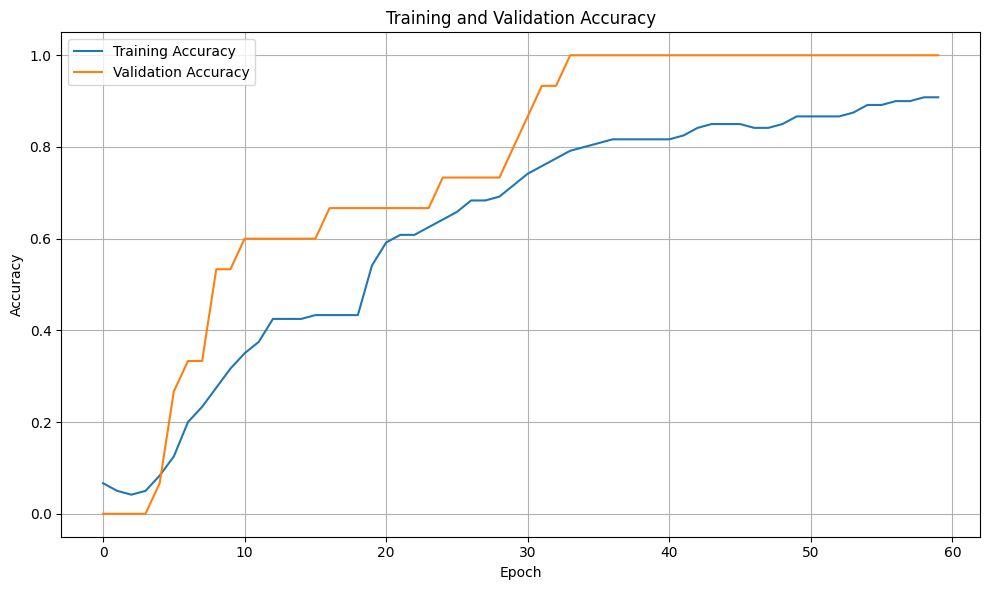

In [52]:
# Accuracy plot
plt.figure(figsize=(10, 6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Loss plot
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# Evaluate
validation_loss, validation_accuracy = model.evaluate(X_validation_processed, y_validation, verbose=0)
print(f"Validation Loss: {validation_loss:.4f}, Validation Accuracy: {validation_accuracy:.4f}")
 
test_loss, test_accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Validation Loss: 0.2724, Validation Accuracy: 1.0000
Test Loss: 0.4301, Test Accuracy: 0.9333


In [55]:
test_probabilities = model.predict(X_test_processed, verbose=0)
y_pred_encoded = np.argmax(test_probabilities, axis=1)
 
y_pred = label_transformer.inverse_transform(y_pred_encoded)
y_test_original = label_transformer.inverse_transform(y_test)
 
manual_accuracy = accuracy_score(y_test, y_pred_encoded)
print(f"Manual test accuracy: {manual_accuracy:.4f}")
 
prediction_results = pd.DataFrame({
    "Actual Class": y_test_original,
    "Predicted Class": y_pred,
    "Correct": y_test_original == y_pred
})
prediction_results.head(20)

Manual test accuracy: 0.9333


,Actual Class,Predicted Class,Correct
0,Iris-virginica,Iris-virginica,True
1,Iris-versicolor,Iris-versicolor,True
2,Iris-virginica,Iris-virginica,True
3,Iris-virginica,Iris-virginica,True
4,Iris-virginica,Iris-virginica,True
...,...,...,...
10,Iris-versicolor,Iris-versicolor,True
11,Iris-versicolor,Iris-virginica,False
12,Iris-setosa,Iris-setosa,True
13,Iris-setosa,Iris-setosa,True


In [58]:
# Attach class probabilities
probability_columns = [f"Probability_{str(c).replace(' ', '_').replace('-', '_')}" for c in label_transformer.classes_]
probability_dataframe = pd.DataFrame(test_probabilities, columns=probability_columns)
 
prediction_results_with_probabilities = pd.concat([prediction_results.reset_index(drop=True), probability_dataframe.reset_index(drop=True)],axis=1)
prediction_results_with_probabilities.head(20)

,Actual Class,Predicted Class,Correct,Probability_Iris_setosa,Probability_Iris_versicolor,Probability_Iris_virginica
0,Iris-virginica,Iris-virginica,True,0.006,0.241,0.753
1,Iris-versicolor,Iris-versicolor,True,0.255,0.494,0.251
2,Iris-virginica,Iris-virginica,True,0.003,0.181,0.816
3,Iris-virginica,Iris-virginica,True,0.007,0.106,0.887
4,Iris-virginica,Iris-virginica,True,0.003,0.050,0.947
...,...,...,...,...,...,...
10,Iris-versicolor,Iris-versicolor,True,0.013,0.614,0.373
11,Iris-versicolor,Iris-virginica,False,0.140,0.374,0.486
12,Iris-setosa,Iris-setosa,True,0.713,0.222,0.065
13,Iris-setosa,Iris-setosa,True,0.794,0.172,0.034
